In [2]:
import pandas as pd
df=pd.read_csv(r"D:\nalini\development\npowercanada\ibm_dataanalyst\module7\c7m1\Walmart_customer_purchases.csv")
df.head()

,Customer_ID,Age,Gender,City,Category,Product_Name,Purchase_Date,Purchase_Amount,Payment_Method,Discount_Applied,Rating,Repeat_Customer
0,84607c1f-910c-44d5-b89f-e1ee06dd34c0,49,Female,New Cynthia,Electronics,Smartphone,2024-08-30,253.26,Cash on Delivery,No,1,Yes
1,f2a81712-a73e-4424-8b39-4c615a0bd4ea,36,Other,Cruzport,Clothing,T-Shirt,2024-12-21,73.19,Debit Card,Yes,1,No
2,da9be287-8b0e-4688-bccd-1a2cdd7567c6,52,Male,Jeffreytown,Beauty,Perfume,2024-12-26,125.62,Credit Card,Yes,1,No
3,50ec6932-3ac7-492f-9e55-4b148212f302,47,Female,Jenniferburgh,Electronics,Smartwatch,2024-11-04,450.32,Credit Card,No,2,Yes
4,8fdc3098-fc75-4b0f-983c-d8d8168c6362,43,Other,Kingshire,Electronics,Smartphone,2024-10-07,369.28,Credit Card,Yes,2,Yes


In [3]:
category_counts = df['Category'].value_counts()
print(category_counts)

Category
Electronics    12642
Home           12492
Beauty         12447
Clothing       12419
Name: count, dtype: int64


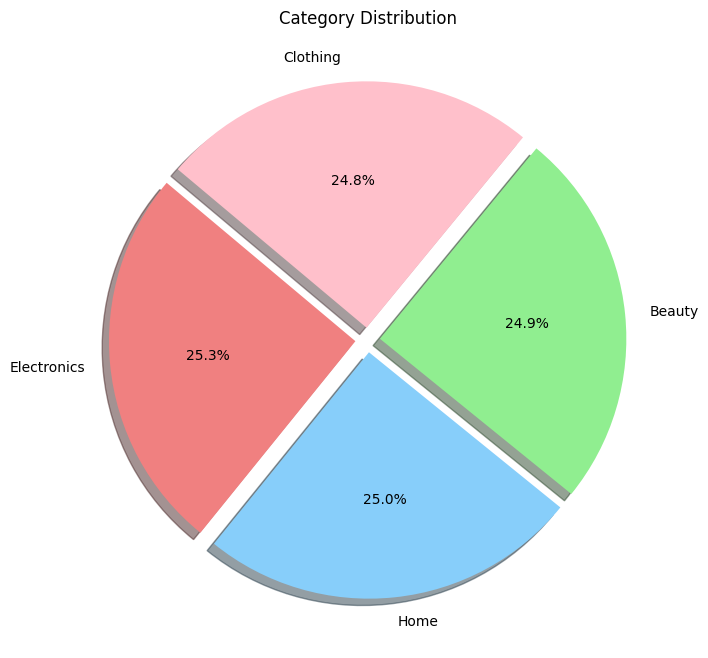

In [4]:
import matplotlib.pyplot as plt
colors_list=['lightcoral', 'lightskyblue', 'lightgreen', 'pink']
explode_list = [0.05, 0.05, 0.05, 0.05]
plt.figure(figsize=(8, 8))
plt.pie(category_counts, labels=category_counts.index, autopct='%1.1f%%',startangle=140,shadow = True,colors=colors_list,explode=explode_list)
plt.title('Category Distribution')
plt.show()



In [5]:
payment_counts = df['Payment_Method'].value_counts()
print(payment_counts)

Payment_Method
Debit Card          12589
Credit Card         12528
Cash on Delivery    12496
UPI                 12387
Name: count, dtype: int64


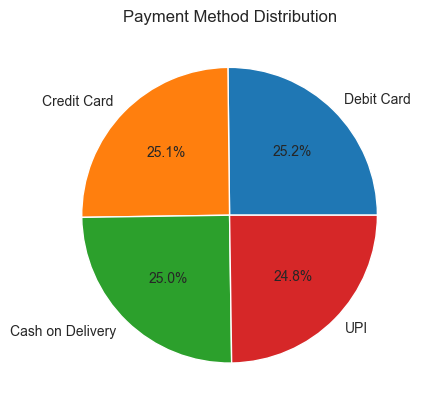

In [6]:
import seaborn as sns
import matplotlib.pyplot as plt
sns.set_style("darkgrid")
plt.pie(payment_counts, labels=payment_counts.index, autopct='%1.1f%%')
plt.title('Payment Method Distribution')
plt.show()

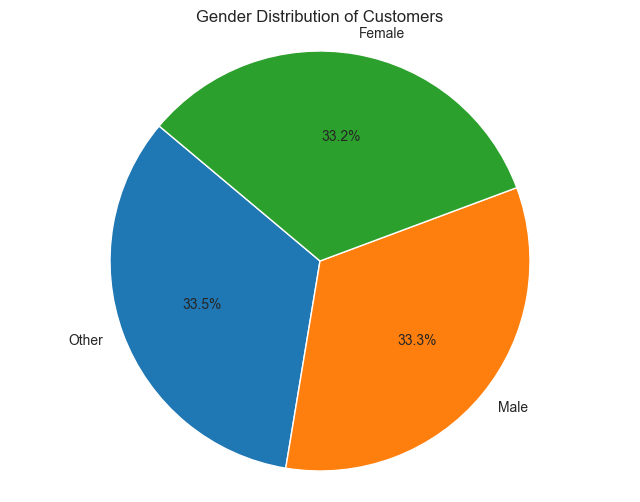

In [7]:
gender_counts = df['Gender'].value_counts()

plt.figure(figsize=(8, 6))
plt.pie(gender_counts, labels=gender_counts.index, autopct='%1.1f%%', startangle=140)
plt.title('Gender Distribution of Customers')
plt.axis('equal')
plt.show()

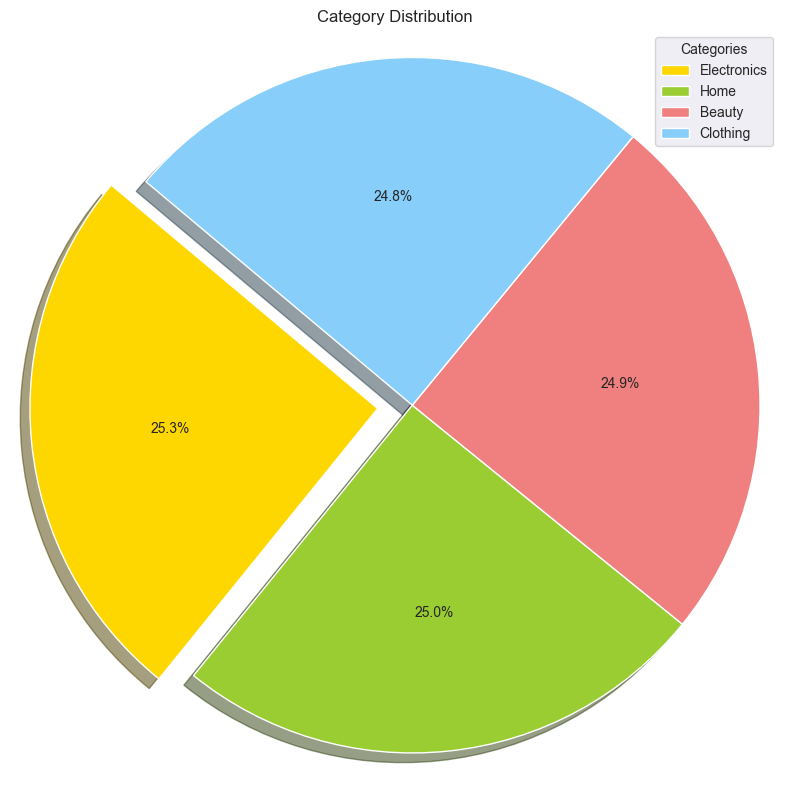

In [8]:
import matplotlib.pyplot as plt

# Custom settings
colors_list = ['gold', 'yellowgreen', 'lightcoral', 'lightskyblue']
explode_list = [0.1, 0, 0, 0]

plt.figure(figsize=(8, 8))

# Create the pie chart
patches, texts, autotexts = plt.pie(
    category_counts, 
    labels=None, 
    autopct='%1.1f%%',
    startangle=140,
    shadow=True,
    colors=colors_list,
    explode=explode_list
)
plt.legend(patches, category_counts.index, title="Categories", loc="best")
plt.title('Category Distribution')
plt.axis('equal') 
plt.tight_layout()
plt.show()

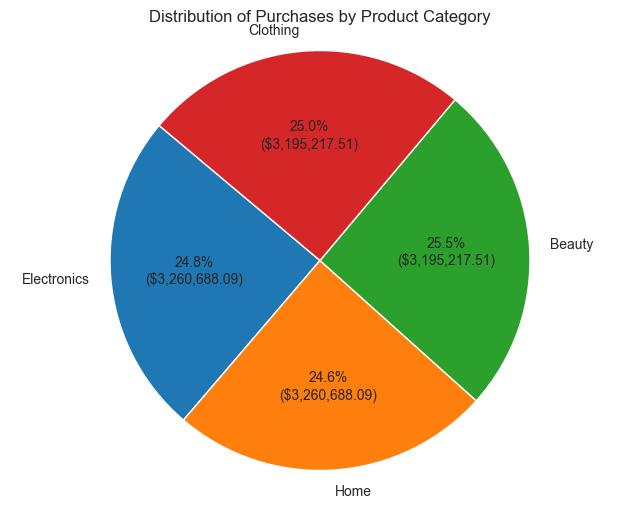

In [9]:
category_amounts = df.groupby('Category')['Purchase_Amount'].sum()
plt.figure(figsize=(8, 6))
plt.pie(category_amounts, labels=category_counts.index, autopct=lambda p: f'{p:.1f}%\n(${category_amounts[category_counts.index].iloc[int(p/100*len(category_counts))]:,.2f})', startangle=140)
plt.title('Distribution of Purchases by Product Category')
plt.axis('equal')  # Equal aspect ratio ensures pie chart is circular
plt.show()

In [10]:
! pip install nbformat

In [11]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd


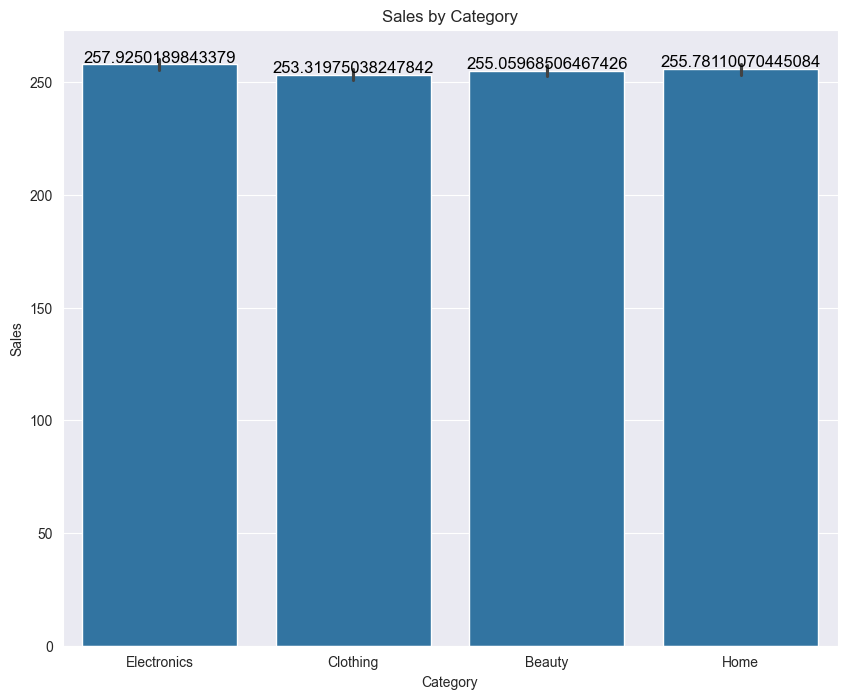

In [12]:
df=pd.read_csv(r"D:\nalini\development\npowercanada\ibm_dataanalyst\module7\c7m1\Walmart_customer_purchases.csv")
plt.figure(figsize=(10 ,8))
ax=sns.barplot(x='Category', y='Purchase_Amount', data=df)

for p in ax.patches:
    ax.annotate(f'{p.get_height()}', 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='center', 
                fontsize=12, color='black', 
                xytext=(0, 5), textcoords='offset points')

plt.title('Sales by Category')
plt.xlabel('Category')
plt.ylabel('Sales')
plt.show()

In [13]:
! pip install plotly

In [14]:
import pandas as pd
import plotly.express as px

# Load your dataset
df = pd.read_csv((r"D:\nalini\development\npowercanada\ibm_dataanalyst\module7\c7m1\Walmart_customer_purchases.csv"))

# Group by Category and sum Purchase Amount
category_purchase = df.groupby('Category')['Purchase_Amount'].sum().sort_values(ascending=False)

# Create Pie Chart
fig = px.pie(
    names=category_purchase.index,
    values=category_purchase.values,
    title='🛍️ Purchase Amount Distribution by Category',
    hole=0.4,
    color_discrete_sequence=px.colors.sequential.Tealgrn
)

# Add labels to the chart
fig.update_traces(textinfo='percent+label')
fig.show(renderer='browser')
#fig.show()

# ✅ Save and open it manually (bypasses all rendering issues)
#fig.write_html("purchase_by_category.html")
#print("Chart saved! Open 'purchase_by_category.html' in your browser.")

In [15]:
! pip install wordcloud

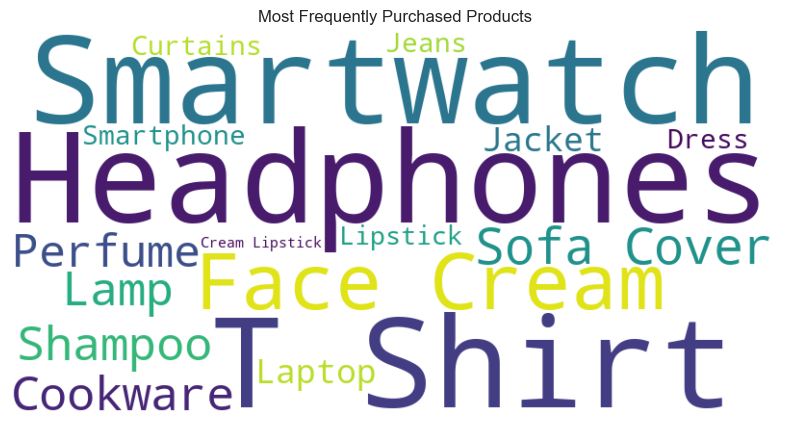

In [16]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

# Combine all product names into one string
text = " ".join(df['Product_Name'].dropna().astype(str))

# Generate word cloud
wordcloud = WordCloud(width=800, height=400, background_color='white').generate(text)

# Plot the word cloud
plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Most Frequently Purchased Products')
plt.show()

In [17]:
!pip install pywaffle



pay {'Debit Card': 12589, 'Credit Card': 12528, 'Cash on Delivery': 12496, 'UPI': 12387}


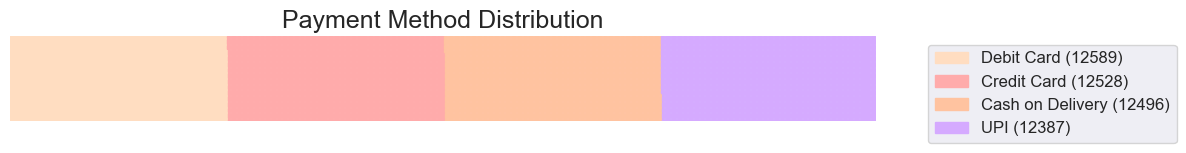

In [18]:
from pywaffle import Waffle
import matplotlib.pyplot as plt

# Count payment methods
payment_counts = df['Payment_Method'].value_counts().to_dict()
print('pay',payment_counts)
data =payment_counts

labels_with_values = [f"{k} ({v})" for k, v in data.items()]
# Create waffle chart
fig = plt.figure(
    FigureClass=Waffle,
    rows=70,
    values=data,
    colors=["#FFDDC1", "#FFABAB", "#FFC3A0", "#D5AAFF"],
    title={'label': 'Payment Method Distribution', 'loc': 'center','fontsize':18},
    legend={'loc': 'upper left', 'bbox_to_anchor': (1.05, 1),'fontsize': 12,'labels':labels_with_values},
    figsize=(12,6)
)
plt.show()

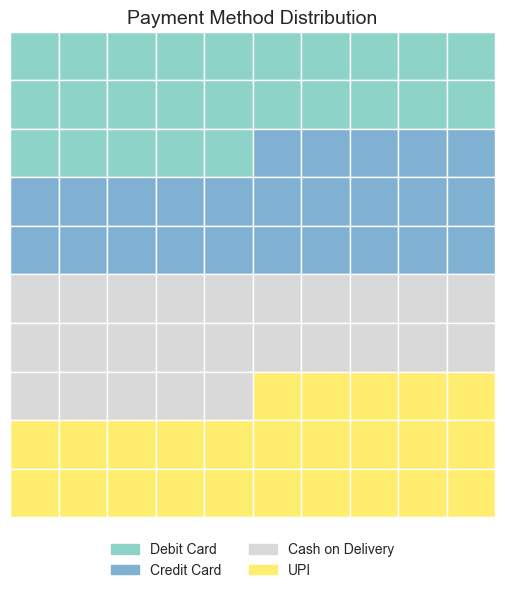

In [19]:
import matplotlib.pyplot as plt
import numpy as np

# Top categories (customize as needed)
payment_counts = df['Payment_Method'].value_counts().head(6)
total = payment_counts.sum()

# Configuration
rows = 10
columns = 10
total_tiles = rows * columns

# Scale to 100 tiles
tile_counts = (payment_counts / total * total_tiles).round().astype(int)

# Fill grid
waffle_grid = []
for category, count in tile_counts.items():
    waffle_grid.extend([category] * count)

# Pad if less than 100
waffle_grid.extend([''] * (total_tiles - len(waffle_grid)))
waffle_matrix = np.array(waffle_grid).reshape((rows, columns))

# Plot
fig, ax = plt.subplots(figsize=(8, 6))
colors = plt.cm.Set3(np.linspace(0, 1, len(tile_counts)))
color_map = dict(zip(tile_counts.index, colors))

for row in range(rows):
    for col in range(columns):
        label = waffle_matrix[row, col]
        color = color_map.get(label, '#EEEEEE')  # Light grey for empty
        ax.add_patch(plt.Rectangle((col, rows - 1 - row), 1, 1,
                                   facecolor=color, edgecolor='white', linewidth=1))

# Cleanup
ax.set_xlim(0, columns)
ax.set_ylim(0, rows)
ax.set_xticks([])
ax.set_yticks([])
ax.set_aspect('equal')
ax.set_title('Payment Method Distribution', fontsize=14)

# Add legend
handles = [plt.Rectangle((0,0),1,1, color=color_map[cat]) for cat in tile_counts.index]
plt.legend(handles, tile_counts.index, loc='lower center', bbox_to_anchor=(0.5, -0.15),
           ncol=2, frameon=False)

plt.tight_layout()
plt.show()

In [20]:

print(df['Payment_Method'].value_counts())

Payment_Method
Debit Card          12589
Credit Card         12528
Cash on Delivery    12496
UPI                 12387
Name: count, dtype: int64


In [21]:
pip install dash plotly pandas dash-bootstrap-components


Note: you may need to restart the kernel to use updated packages.


In [22]:
import dash
from dash import dcc, html
import dash_bootstrap_components as dbc
import pandas as pd
import plotly.express as px

# Load your Walmart dataset
#df = pd.read_csv('walmart.csv')  # 🔁 Replace with your CSV filename

# Create figures
def create_pie_chart():
    payment_counts = df['Payment_Method'].value_counts()
    fig = px.pie(
        names=payment_counts.index,
        values=payment_counts.values,
        title='Payment Method Distribution',
        hole=0.3
    )
    return fig

def create_bar_chart():
    category_sales = df.groupby('Category')['Purchase_Amount'].sum().sort_values(ascending=False)
    fig = px.bar(
        x=category_sales.index,
        y=category_sales.values,
        labels={'x': 'Category', 'y': 'Total Sales'},
        title='Sales by Category',
        color=category_sales.index
    )
    return fig

# Initialize Dash app
app = dash.Dash(__name__, external_stylesheets=[dbc.themes.BOOTSTRAP])
app.title = "Walmart Dashboard"

# Layout
app.layout = dbc.Container([
    html.H1("🛒 Walmart Customer Purchase Dashboard", className='text-center my-4'),

    dbc.Row([
        dbc.Col(dcc.Graph(figure=create_pie_chart()), md=6),
        dbc.Col(dcc.Graph(figure=create_bar_chart()), md=6),
    ])
], fluid=True)

# Run the app
if __name__ == '__main__':
    app.run(debug=True)


In [25]:
import pandas as pd
from dash import Dash, dcc, html, Input, Output
import plotly.express as px

# Load the dataset
df = pd.read_csv("Walmart_customer_purchases.csv")
df['Purchase_Date'] = pd.to_datetime(df['Purchase_Date'])

# Initialize the Dash app
app = Dash(__name__)
app.title = "Walmart Customer Purchase Dashboard"

# App layout
app.layout = html.Div([
    html.H1("Walmart Customer Purchase Dashboard", style={'textAlign': 'center'}),

    html.Div([
        html.Label("Filter by Gender:"),
        dcc.Dropdown(df['Gender'].unique(), value=None, placeholder="Select Gender", id='gender-filter'),
        
        html.Label("Filter by Repeat Customer:"),
        dcc.Dropdown(df['Repeat_Customer'].unique(), value=None, placeholder="Select Repeat Status", id='repeat-filter'),

        html.Label("Filter by Category:"),
        dcc.Dropdown(df['Category'].unique(), value=None, placeholder="Select Category", id='category-filter'),
    ], style={'width': '25%', 'display': 'inline-block', 'verticalAlign': 'top', 'padding': '20px'}),

    html.Div([
        dcc.Graph(id='gender-pie'),
        dcc.Graph(id='category-bar'),
        dcc.Graph(id='sales-trend'),
    ], style={'width': '70%', 'display': 'inline-block'}),
])

# Callbacks for interactivity
@app.callback(
    Output('gender-pie', 'figure'),
    Output('category-bar', 'figure'),
    Output('sales-trend', 'figure'),
    Input('gender-filter', 'value'),
    Input('repeat-filter', 'value'),
    Input('category-filter', 'value'),
)
def update_graphs(gender, repeat, category):
    filtered_df = df.copy()
    if gender:
        filtered_df = filtered_df[filtered_df['Gender'] == gender]
    if repeat:
        filtered_df = filtered_df[filtered_df['Repeat_Customer'] == repeat]
    if category:
        filtered_df = filtered_df[filtered_df['Category'] == category]

    # Pie Chart
    pie_fig = px.pie(filtered_df, names='Gender', title='Gender Distribution')

    # Bar Chart
    bar_fig = px.bar(
        filtered_df.groupby('Category')['Purchase_Amount'].sum().reset_index(),
        x='Category', y='Purchase_Amount', title='Total Purchase Amount by Category'
    )

    # Sales Trend
    trend_df = filtered_df.groupby('Purchase_Date')['Purchase_Amount'].sum().reset_index()
    trend_fig = px.line(trend_df, x='Purchase_Date', y='Purchase_Amount', title='Sales Over Time')

    return pie_fig, bar_fig, trend_fig

# Run the app
if __name__ == '__main__':
    app.run(debug=True)


In [24]:
import pandas as pd
from dash import Dash, dcc, html, Input, Output
import plotly.express as px

# Load and prepare data
df = pd.read_csv("Walmart_customer_purchases.csv")
df['Purchase_Date'] = pd.to_datetime(df['Purchase_Date'])

# Initialize app
app = Dash(__name__)
app.title = "Walmart Customer Dashboard"

# App Layout
app.layout = html.Div(style={'backgroundColor': '#f9f9f9', 'fontFamily': 'Arial'}, children=[
    html.H1("Walmart Customer Purchase Dashboard", style={'textAlign': 'center', 'color': '#2c3e50'}),

    # KPI Cards
    html.Div([
        html.Div([
            html.H4("Total Sales", style={'color': '#2980b9'}),
            html.H2(f"${df['Purchase_Amount'].sum():,.0f}", style={'color': '#2c3e50'})
        ], className='card'),
        
        html.Div([
            html.H4("Avg Purchase", style={'color': '#27ae60'}),
            html.H2(f"${df['Purchase_Amount'].mean():.2f}", style={'color': '#2c3e50'})
        ], className='card'),
        
        html.Div([
            html.H4("Unique Customers", style={'color': '#8e44ad'}),
            html.H2(df['Customer_ID'].nunique(), style={'color': '#2c3e50'})
        ], className='card'),
    ], style={'display': 'flex', 'justifyContent': 'space-around', 'padding': '20px'}),

    # Filters
    html.Div([
        html.Label("Filter by Gender:"),
        dcc.Dropdown(df['Gender'].unique(), placeholder="Select Gender", id='gender-filter'),
        html.Label("Filter by Repeat Customer:"),
        dcc.Dropdown(df['Repeat_Customer'].unique(), placeholder="Repeat Customer", id='repeat-filter'),
        html.Label("Filter by Category:"),
        dcc.Dropdown(df['Category'].unique(), placeholder="Select Category", id='category-filter'),
    ], style={'width': '25%', 'display': 'inline-block', 'padding': '20px'}),

    # Graphs
    html.Div([
        dcc.Graph(id='gender-pie'),
        dcc.Graph(id='category-bar'),
        dcc.Graph(id='sales-trend'),
    ], style={'width': '70%', 'display': 'inline-block', 'padding': '10px', 'verticalAlign': 'top'})
])

# Callback for interactivity
@app.callback(
    Output('gender-pie', 'figure'),
    Output('category-bar', 'figure'),
    Output('sales-trend', 'figure'),
    Input('gender-filter', 'value'),
    Input('repeat-filter', 'value'),
    Input('category-filter', 'value'),
)
def update_graphs(gender, repeat, category):
    filtered_df = df.copy()
    if gender:
        filtered_df = filtered_df[filtered_df['Gender'] == gender]
    if repeat:
        filtered_df = filtered_df[filtered_df['Repeat_Customer'] == repeat]
    if category:
        filtered_df = filtered_df[filtered_df['Category'] == category]

    pie_fig = px.pie(filtered_df, names='Gender', title='Gender Distribution', template='plotly_dark')
    bar_fig = px.bar(
        filtered_df.groupby('Category')['Purchase_Amount'].sum().reset_index(),
        x='Category', y='Purchase_Amount', title='Total Purchase Amount by Category', template='plotly_dark'
    )
    trend_fig = px.line(
        filtered_df.groupby('Purchase_Date')['Purchase_Amount'].sum().reset_index(),
        x='Purchase_Date', y='Purchase_Amount', title='Sales Over Time', template='plotly_dark'
    )

    return pie_fig, bar_fig, trend_fig

# External CSS for card styling
app.index_string = '''
<!DOCTYPE html>
<html>
    <head>
        {%metas%}
        <title>{%title%}</title>
        {%favicon%}
        {%css%}
        <style>
            .card {
                background-color: white;
                border-radius: 10px;
                padding: 20px;
                width: 30%;
                text-align: center;
                box-shadow: 2px 2px 8px rgba(0,0,0,0.1);
            }
        </style>
    </head>
    <body>
        {%app_entry%}
        <footer>
            {%config%}
            {%scripts%}
            {%renderer%}
        </footer>
    </body>
</html>
'''

# Run app
if __name__ == '__main__':
    app.run(debug=True)


In [ ]:
import pandas as pd
from dash import Dash, dcc, html, Input, Output
import plotly.express as px

# Load and prepare data
df = pd.read_csv("Walmart_customer_purchases.csv")
df['Purchase_Date'] = pd.to_datetime(df['Purchase_Date'])

# Initialize app
app = Dash(__name__)
app.title = "Walmart Customer Dashboard"

# App Layout
app.layout = html.Div(style={'backgroundColor': '#f9f9f9', 'fontFamily': 'Arial'}, children=[
    html.H1("Walmart Customer Purchase Dashboard", style={'textAlign': 'center', 'color': '#2c3e50'}),

    # KPI Cards
    html.Div([
    html.Div([
        html.H4("Total Sales", style={'color': '#2980b9'}),
        html.H2(id='total-sales', style={'color': '#2c3e50'})
    ], className='card'),

    html.Div([
        html.H4("Avg Purchase", style={'color': '#27ae60'}),
        html.H2(id='avg-purchase', style={'color': '#2c3e50'})
    ], className='card'),

    html.Div([
        html.H4("Unique Customers", style={'color': '#8e44ad'}),
        html.H2(id='unique-customers', style={'color': '#2c3e50'})
    ], className='card'),
], style={'display': 'flex', 'justifyContent': 'space-around', 'padding': '20px'}),


   
    # Filters
    html.Div([
        html.Label("Filter by Gender:"),
        dcc.Dropdown(df['Gender'].unique(), placeholder="Select Gender", id='gender-filter'),
        html.Label("Filter by Repeat Customer:"),
        dcc.Dropdown(df['Repeat_Customer'].unique(), placeholder="Repeat Customer", id='repeat-filter'),
        html.Label("Filter by Category:"),
        dcc.Dropdown(df['Category'].unique(), placeholder="Select Category", id='category-filter'),
    ], style={'width': '25%', 'display': 'inline-block', 'padding': '20px'}),

    # Graphs
    html.Div([
        dcc.Graph(id='gender-pie'),
        dcc.Graph(id='category-bar'),
        dcc.Graph(id='sales-trend'),
    ], style={'width': '70%', 'display': 'inline-block', 'padding': '10px', 'verticalAlign': 'top'})
])

# Callback for interactivity
from dash import Output, Input

@app.callback(
    Output('gender-pie', 'figure'),
    Output('category-bar', 'figure'),
    Output('sales-trend', 'figure'),
    Output('total-sales', 'children'),
    Output('avg-purchase', 'children'),
    Output('unique-customers', 'children'),
    Input('gender-filter', 'value'),
    Input('repeat-filter', 'value'),
    Input('category-filter', 'value'),
)
def update_dashboard(gender, repeat, category):
    filtered_df = df.copy()
    if gender:
        filtered_df = filtered_df[filtered_df['Gender'] == gender]
    if repeat:
        filtered_df = filtered_df[filtered_df['Repeat_Customer'] == repeat]
    if category:
        filtered_df = filtered_df[filtered_df['Category'] == category]

    # Pie Chart
    pie_fig = px.pie(filtered_df, names='Gender', title='Gender Distribution', template='plotly_dark')

    # Bar Chart
    bar_fig = px.bar(
        filtered_df.groupby('Category')['Purchase_Amount'].sum().reset_index(),
        x='Category', y='Purchase_Amount', title='Total Purchase Amount by Category', template='plotly_dark'
    )

    # Line Chart
    trend_fig = px.line(
        filtered_df.groupby('Purchase_Date')['Purchase_Amount'].sum().reset_index(),
        x='Purchase_Date', y='Purchase_Amount', title='Sales Over Time', template='plotly_dark'
    )

    # Dynamic KPIs
    total_sales = f"${filtered_df['Purchase_Amount'].sum():,.0f}"
    avg_purchase = f"${filtered_df['Purchase_Amount'].mean():.2f}" if not filtered_df.empty else "$0.00"
    unique_customers = filtered_df['Customer_ID'].nunique()

    return pie_fig, bar_fig, trend_fig, total_sales, avg_purchase, unique_customers


# External CSS for card styling
app.index_string = '''
<!DOCTYPE html>
<html>
    <head>
        {%metas%}
        <title>{%title%}</title>
        {%favicon%}
        {%css%}
        <style>
            .card {
                background-color: white;
                border-radius: 10px;
                padding: 20px;
                width: 30%;
                text-align: center;
                box-shadow: 2px 2px 8px rgba(0,0,0,0.1);
            }
        </style>
    </head>
    <body>
        {%app_entry%}
        <footer>
            {%config%}
            {%scripts%}
            {%renderer%}
        </footer>
    </body>
</html>
'''

# Run app
if __name__ == '__main__':
    app.run(debug=True)
